# Détection du Cancer du sein — v2 (Fine-tuning amélioré)

In [ ]:
# Vérifie si le GPU est utilisé
import torch
print("GPU disponible:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Nom du GPU:", torch.cuda.get_device_name(0))

GPU disponible: True
Nom du GPU: Tesla T4


In [ ]:
# Se connecter sur Kaggle
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"nafissatousow","key":"556c870f75609f6a940bc702fc75b189"}'}

In [ ]:
!pip install -q kaggle
!pip install -q tqdm seaborn

In [ ]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

## 1. Télécharger le Dataset

In [ ]:
import kagglehub

path = kagglehub.dataset_download("awsaf49/cbis-ddsm-breast-cancer-image-dataset")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cbis-ddsm-breast-cancer-image-dataset' dataset.
Path to dataset files: /kaggle/input/cbis-ddsm-breast-cancer-image-dataset


## 2. Importer les librairies et charger les données

In [ ]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# Charger les données CSV
mass_train = pd.read_csv(os.path.join(path, 'csv', 'mass_case_description_train_set.csv'))
mass_test  = pd.read_csv(os.path.join(path, 'csv', 'mass_case_description_test_set.csv'))
calc_train = pd.read_csv(os.path.join(path, 'csv', 'calc_case_description_train_set.csv'))
calc_test  = pd.read_csv(os.path.join(path, 'csv', 'calc_case_description_test_set.csv'))

print("Données chargées avec succès !")

Données chargées avec succès !


## 3. Nettoyage et création des labels

In [ ]:
def clean_labels(df):
    df = df[df['pathology'].isin(['BENIGN', 'MALIGNANT'])].copy()
    df['label'] = df['pathology'].map({'BENIGN': 0, 'MALIGNANT': 1})
    return df

train_df = pd.concat([clean_labels(mass_train), clean_labels(calc_train)])
test_df  = pd.concat([clean_labels(mass_test),  clean_labels(calc_test)])

print("Distribution initiale:")
print("Train:", train_df['label'].value_counts().to_dict())
print("Test: ", test_df['label'].value_counts().to_dict())

Distribution initiale:
Train: {1: 1181, 0: 1105}
Test:  {0: 324, 1: 276}


## 4. Construction des chemins d'accès aux images

In [ ]:
def build_image_paths(df, base_path):
    full_paths = []
    labels = []
    missing_folders = 0
    found_folders = 0

    for _, row in df.iterrows():
        try:
            # Méthode 1: Utiliser le chemin complet du fichier image
            if 'image file path' in df.columns and pd.notna(row['image file path']):
                # Extraire l'UID du chemin complet
                path_parts = row['image file path'].split('/')
                # Le dernier élément est le nom du fichier, l'avant-dernier est le dossier
                if len(path_parts) >= 2:
                    uid = path_parts[-2]  # Le dossier parent

                    # Chercher dans différents répertoires possibles
                    possible_paths = [
                        os.path.join(base_path, "jpeg", uid),
                        os.path.join(base_path, "jpeg", uid.split('.')[0]),  # Sans extension
                    ]

                    for folder_path in possible_paths:
                        if os.path.exists(folder_path) and os.path.isdir(folder_path):
                            found_folders += 1
                            for file in os.listdir(folder_path):
                                if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                                    full_paths.append(os.path.join(folder_path, file))
                                    labels.append(row['label'])
                            break
                    else:
                        missing_folders += 1

        except Exception as e:
            print(f"Erreur pour une ligne: {e}")
            continue

    print(f"Dossiers trouvés: {found_folders}, manquants: {missing_folders}")
    return full_paths, labels

print("Construction des chemins pour l'entraînement...")
train_paths, train_labels = build_image_paths(train_df, path)

print("\nConstruction des chemins pour le test...")
test_paths, test_labels = build_image_paths(test_df, path)

print(f"\nTrain images: {len(train_paths)}")
print(f"Test images:  {len(test_paths)}")

Construction des chemins pour l'entraînement...
Dossiers trouvés: 2286, manquants: 0

Construction des chemins pour le test...
Dossiers trouvés: 600, manquants: 0

Train images: 2286
Test images:  600


## 5. Création du sous-ensemble équilibré

In [ ]:
def create_balanced_subset(image_paths, labels, samples_per_class=500):
    paths_array  = np.array(image_paths)
    labels_array = np.array(labels)
    selected_paths, selected_labels = [], []

    for class_label in [0, 1]:
        class_indices = np.where(labels_array == class_label)[0]
        n_samples = min(samples_per_class, len(class_indices))
        selected = np.random.choice(class_indices, n_samples, replace=False)
        selected_paths.extend(paths_array[selected])
        selected_labels.extend(labels_array[selected])
        print(f"Classe {class_label} ({'BENIGN' if class_label==0 else 'MALIGNANT'}): {n_samples} images")

    indices = np.random.permutation(len(selected_paths))
    return [selected_paths[i] for i in indices], [selected_labels[i] for i in indices]

print("=" * 50)
print("SOUS-ENSEMBLE TRAIN (500/classe)")
train_paths_s, train_labels_s = create_balanced_subset(train_paths, train_labels, 500)

print("\nSOUS-ENSEMBLE TEST (200/classe)")
test_paths_s, test_labels_s = create_balanced_subset(test_paths, test_labels, 200)

print(f"\nTotal train: {len(train_paths_s)} | Total test: {len(test_paths_s)}")

SOUS-ENSEMBLE TRAIN (500/classe)
Classe 0 (BENIGN): 500 images
Classe 1 (MALIGNANT): 500 images

SOUS-ENSEMBLE TEST (200/classe)
Classe 0 (BENIGN): 200 images
Classe 1 (MALIGNANT): 200 images

Total train: 1000 | Total test: 400


## 6. Dataset PyTorch avec augmentation
> **Nouveauté v2** : transformations d'augmentation sur le jeu d'entraînement (flip, rotation, colorjitter)

In [ ]:
class MammographyDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels      = labels
        self.transform   = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('L')
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label


# --- Transformations TRAIN avec augmentation ---
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# --- Transformations TEST sans augmentation ---
test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset = MammographyDataset(train_paths_s, train_labels_s, transform=train_transform)
test_dataset  = MammographyDataset(test_paths_s,  test_labels_s,  transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset)} images | Test: {len(test_dataset)} images")

Train: 1000 images | Test: 400 images


## 7. Modèle ResNet18 avec fine-tuning des couches profondes
> **Nouveauté v2** : `layer3`, `layer4` et `fc` sont dégelés pour un vrai fine-tuning

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation de: {device}")

model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# --- Geler toutes les couches d'abord ---
for param in model.parameters():
    param.requires_grad = False

# --- Dégeler layer3, layer4 et fc ---
for name, param in model.named_parameters():
    if any(x in name for x in ["layer3", "layer4", "fc"]):
        param.requires_grad = True

# Remplacer la dernière couche
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_features, 2)
)

model = model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Paramètres totaux:      {total_params:,}")
print(f"Paramètres entraînables:{trainable_params:,} ({100*trainable_params/total_params:.1f}%)")

Utilisation de: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 209MB/s]


Paramètres totaux:      11,177,538
Paramètres entraînables:10,494,466 (93.9%)


## 8. Fonction d'entraînement avec scheduler
> **Nouveauté v2** : learning rates différenciés par couche + `ReduceLROnPlateau`

In [ ]:
def train_model(model, train_loader, test_loader, epochs=10):
    criterion = nn.CrossEntropyLoss()

    # Learning rates différenciés : couches profondes plus douces
    optimizer = optim.Adam([
        {'params': model.layer3.parameters(), 'lr': 1e-4},
        {'params': model.layer4.parameters(), 'lr': 1e-4},
        {'params': model.fc.parameters(),     'lr': 1e-3},
    ])

    # Réduire le LR si la val accuracy stagne
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', patience=2, factor=0.5
    )

    train_losses, test_losses = [], []
    train_accs,   test_accs   = [], []
    best_acc = 0.0

    print("\n" + "=" * 50)
    print("DÉBUT DE L'ENTRAÎNEMENT")
    print("=" * 50)

    for epoch in range(epochs):
        # --- Train ---
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} - Train"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss    += loss.item()
            _, predicted   = outputs.max(1)
            train_total   += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()

        # --- Validation ---
        model.eval()
        test_loss, test_correct, test_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in tqdm(test_loader, desc=f"Epoch {epoch+1}/{epochs} - Test"):
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss    = criterion(outputs, labels)
                test_loss    += loss.item()
                _, predicted  = outputs.max(1)
                test_total   += labels.size(0)
                test_correct += predicted.eq(labels).sum().item()

        # --- Métriques ---
        train_loss_e = train_loss / len(train_loader)
        test_loss_e  = test_loss  / len(test_loader)
        train_acc    = 100.0 * train_correct / train_total
        test_acc     = 100.0 * test_correct  / test_total

        train_losses.append(train_loss_e)
        test_losses.append(test_loss_e)
        train_accs.append(train_acc)
        test_accs.append(test_acc)

        # Scheduler step
        scheduler.step(test_acc)

        # Sauvegarder le meilleur modèle
        if test_acc > best_acc:
            best_acc = test_acc
            torch.save(model.state_dict(), 'best_model.pth')
            print(f"  ✅ Meilleur modèle sauvegardé (acc={best_acc:.2f}%)")

        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"  Train — Loss: {train_loss_e:.4f}, Acc: {train_acc:.2f}%")
        print(f"  Test  — Loss: {test_loss_e:.4f},  Acc: {test_acc:.2f}%")
        print("-" * 40)

    print(f"\n🏆 Meilleure précision obtenue: {best_acc:.2f}%")
    return train_losses, test_losses, train_accs, test_accs

## 9. Lancement de l'entraînement

In [ ]:
train_losses, test_losses, train_accs, test_accs = train_model(
    model, train_loader, test_loader, epochs=10
)


DÉBUT DE L'ENTRAÎNEMENT


Epoch 1/10 - Test: 100%|██████████| 25/25 [01:14<00:00,  2.99s/it]


  ✅ Meilleur modèle sauvegardé (acc=50.75%)

Epoch 1/10
  Train — Loss: 0.7631, Acc: 53.90%
  Test  — Loss: 0.8815,  Acc: 50.75%
----------------------------------------


Epoch 2/10 - Test: 100%|██████████| 25/25 [01:13<00:00,  2.93s/it]


  ✅ Meilleur modèle sauvegardé (acc=52.75%)

Epoch 2/10
  Train — Loss: 0.7622, Acc: 52.90%
  Test  — Loss: 0.7181,  Acc: 52.75%
----------------------------------------


...

  ✅ Meilleur modèle sauvegardé (acc=58.50%)

Epoch 8/10
  Train — Loss: 0.6310, Acc: 65.60%
  Test  — Loss: 0.6827,  Acc: 58.50%
----------------------------------------


Epoch 9/10 - Test: 100%|██████████| 25/25 [01:13<00:00,  2.95s/it]



Epoch 9/10
  Train — Loss: 0.6336, Acc: 63.60%
  Test  — Loss: 0.7445,  Acc: 56.75%
----------------------------------------


Epoch 10/10 - Test: 100%|██████████| 25/25 [01:13<00:00,  2.94s/it]

  ✅ Meilleur modèle sauvegardé (acc=59.50%)

Epoch 10/10
  Train — Loss: 0.6166, Acc: 65.60%
  Test  — Loss: 0.6980,  Acc: 59.50%
----------------------------------------

🏆 Meilleure précision obtenue: 59.50%


## 10. Visualisation des résultats

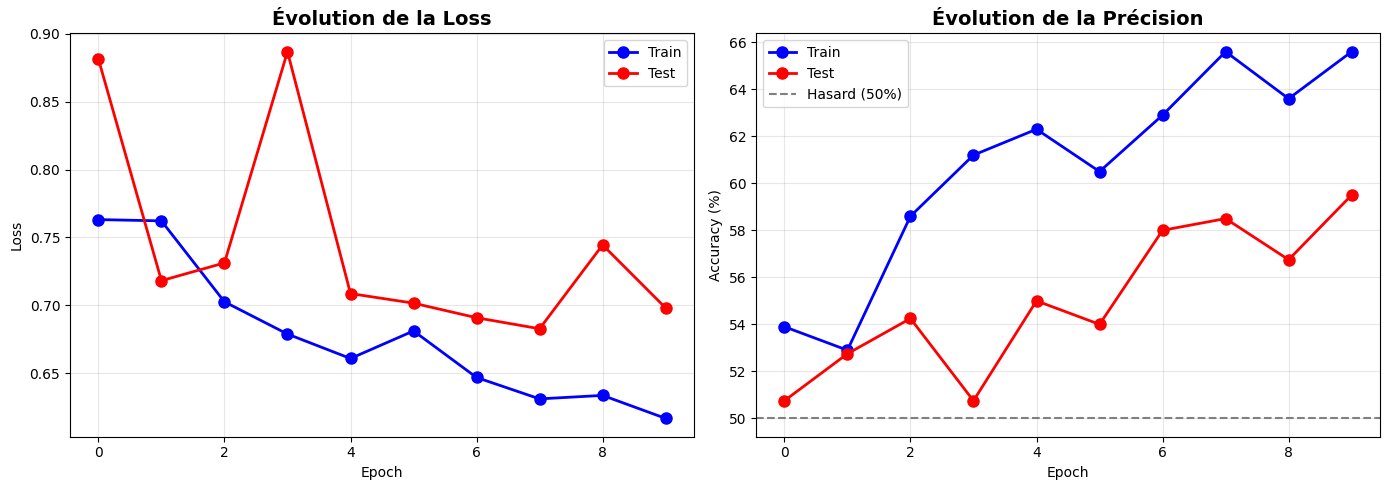

Précision finale (dernière epoch): 59.50%
Meilleure précision:               59.50%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, 'b-o', label='Train', linewidth=2, markersize=8)
axes[0].plot(test_losses,  'r-o', label='Test',  linewidth=2, markersize=8)
axes[0].set_title('Évolution de la Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_accs, 'b-o', label='Train', linewidth=2, markersize=8)
axes[1].plot(test_accs,  'r-o', label='Test',  linewidth=2, markersize=8)
axes[1].axhline(y=50, color='gray', linestyle='--', label='Hasard (50%)')
axes[1].set_title('Évolution de la Précision', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Précision finale (dernière epoch): {test_accs[-1]:.2f}%")
print(f"Meilleure précision:               {max(test_accs):.2f}%")

## 11. Évaluation détaillée (meilleur modèle)

Évaluation: 100%|██████████| 25/25 [01:16<00:00,  3.06s/it]


RAPPORT DE CLASSIFICATION
              precision    recall  f1-score   support

      BENIGN       0.62      0.50      0.55       200
   MALIGNANT       0.58      0.69      0.63       200

    accuracy                           0.59       400
   macro avg       0.60      0.59      0.59       400
weighted avg       0.60      0.59      0.59       400



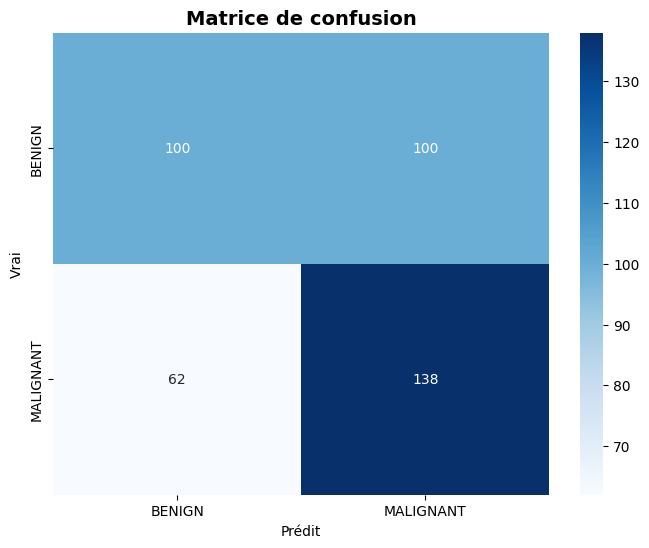


ANALYSE PAR CLASSE
BENIGN: 100/200 = 50.0%
MALIGNANT: 138/200 = 69.0%


In [ ]:
# Charger le meilleur modèle sauvegardé
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Évaluation"):
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\n" + "=" * 50)
print("RAPPORT DE CLASSIFICATION")
print("=" * 50)
print(classification_report(all_labels, all_preds,
                             target_names=['BENIGN', 'MALIGNANT']))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['BENIGN', 'MALIGNANT'],
            yticklabels=['BENIGN', 'MALIGNANT'])
plt.title('Matrice de confusion', fontsize=14, fontweight='bold')
plt.ylabel('Vrai')
plt.xlabel('Prédit')
plt.show()

print("\n" + "=" * 50)
print("ANALYSE PAR CLASSE")
print("=" * 50)
for i, class_name in enumerate(['BENIGN', 'MALIGNANT']):
    class_correct = cm[i, i]
    class_total   = cm[i, :].sum()
    class_acc     = 100.0 * class_correct / class_total
    print(f"{class_name}: {class_correct}/{class_total} = {class_acc:.1f}%")

## 12. Visualisation de quelques prédictions

EXEMPLES DE PRÉDICTIONS


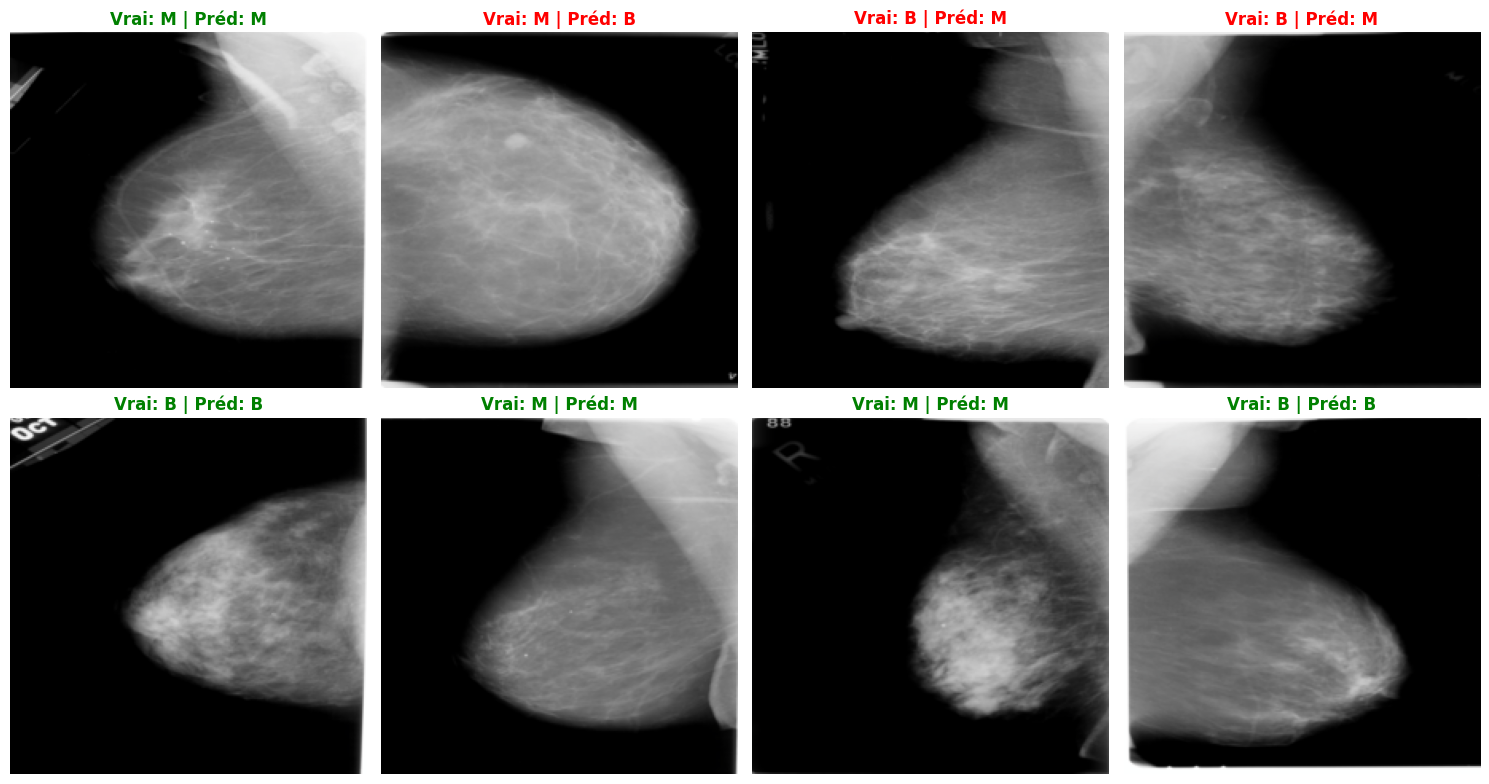

In [ ]:
def show_predictions(model, dataset, num_images=8):
    model.eval()
    n_cols = 4
    n_rows = (num_images + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = axes.flatten()
    indices = np.random.choice(len(dataset), num_images, replace=False)

    with torch.no_grad():
        for i, idx in enumerate(indices):
            img, label = dataset[idx]
            output = model(img.unsqueeze(0).to(device))
            _, pred = output.max(1)

            img_display = img.cpu().permute(1, 2, 0).numpy()
            img_display = np.array([0.229, 0.224, 0.225]) * img_display + np.array([0.485, 0.456, 0.406])
            img_display = np.clip(img_display, 0, 1)

            axes[i].imshow(img_display)
            axes[i].axis('off')
            color     = 'green' if pred.item() == label else 'red'
            vrai      = 'M' if label == 1 else 'B'
            pred_text = 'M' if pred.item() == 1 else 'B'
            axes[i].set_title(f"Vrai: {vrai} | Préd: {pred_text}", color=color, fontweight='bold')

    for i in range(num_images, len(axes)):
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

print("=" * 50)
print("EXEMPLES DE PRÉDICTIONS")
print("=" * 50)
show_predictions(model, test_dataset, num_images=8)

## 13. Sauvegarde finale du modèle

In [ ]:
model_path = 'mammography_model_v2.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'train_losses': train_losses,
    'test_losses':  test_losses,
    'train_accs':   train_accs,
    'test_accs':    test_accs,
    'model_config': {
        'architecture':   'resnet18',
        'fine_tuned':     'layer3, layer4, fc',
        'num_classes':    2,
        'input_size':     224,
        'augmentation':   'flip, rotation, colorjitter',
        'best_test_acc':  max(test_accs)
    }
}, model_path)

print(f"✅ Modèle sauvegardé sous '{model_path}'")
print(f"   Taille: {os.path.getsize(model_path) / 1e6:.2f} MB")

✅ Modèle sauvegardé sous 'mammography_model_v2.pth'
   Taille: 44.79 MB


## 14. Résumé et conclusions

In [ ]:
print("\n" + "=" * 60)
print("RÉSUMÉ DU PROJET — v2")
print("=" * 60)
print(f"""
📊 RÉSULTATS OBTENUS
--------------------
• Meilleure précision test : {max(test_accs):.2f}%
• Précision dernière epoch : {test_accs[-1]:.2f}%
• Loss finale              : {test_losses[-1]:.4f}

🔧 AMÉLIORATIONS APPORTÉES (v1 → v2)
--------------------------------------
✅ Dégel de layer3 + layer4 (fine-tuning réel)
✅ Learning rates différenciés par couche
✅ ReduceLROnPlateau scheduler
✅ Augmentation des données (flip, rotation, colorjitter)
✅ Dropout(0.3) avant la couche de classification
✅ Sauvegarde automatique du meilleur modèle
✅ 10 epochs

📈 PISTES D'AMÉLIORATION SUPPLÉMENTAIRES
-----------------------------------------
1. Passer à ResNet50 ou EfficientNet
2. Dégeler toutes les couches avec un LR très faible (1e-5)
3. Utiliser toutes les images disponibles (pas de sous-ensemble)
4. Ajouter une validation croisée k-fold
""")


RÉSUMÉ DU PROJET — v2

📊 RÉSULTATS OBTENUS
--------------------
• Meilleure précision test : 59.50%
• Précision dernière epoch : 59.50%
• Loss finale              : 0.6980

🔧 AMÉLIORATIONS APPORTÉES (v1 → v2)
--------------------------------------
✅ Dégel de layer3 + layer4 (fine-tuning réel)
✅ Learning rates différenciés par couche
✅ ReduceLROnPlateau scheduler
✅ Augmentation des données (flip, rotation, colorjitter)
✅ Dropout(0.3) avant la couche de classification
✅ Sauvegarde automatique du meilleur modèle
✅ 10 epochs

📈 PISTES D'AMÉLIORATION SUPPLÉMENTAIRES
-----------------------------------------
1. Passer à ResNet50 ou EfficientNet
2. Dégeler toutes les couches avec un LR très faible (1e-5)
3. Utiliser toutes les images disponibles (pas de sous-ensemble)
4. Ajouter une validation croisée k-fold

